In [1]:
# Import Libraries

import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
# Extract ZIP File

zip_path = "/content/dataset (1).zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
# Dataset Path

dataset_path = "/content/dataset/dataset/faces"

print(os.listdir(dataset_path))

['Deepika', 'Disha', 'Akshay', 'Aamir', 'Ileana', 'Farhan', 'Amitabh', 'Ajay', 'Alia']


In [4]:
# Initialize Variables

images = []
labels = []

label_map = {}

current_label = 0

In [5]:
# Read Images

for person_name in sorted(os.listdir(dataset_path)):

    person_folder = os.path.join(dataset_path, person_name)

    if os.path.isdir(person_folder):

        label_map[current_label] = person_name

        for image_name in sorted(os.listdir(person_folder)):

            image_path = os.path.join(person_folder, image_name)

            # Read image
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            # Histogram Equalization
            img = cv2.equalizeHist(img)

            # Resize image
            img = cv2.resize(img, (100, 100))

            # Flatten image
            img = img.flatten()

            images.append(img)

            labels.append(current_label)

        current_label += 1

print("Images Loaded Successfully")

Images Loaded Successfully


In [6]:
# Convert to NumPy Arrays

X = np.array(images)

y = np.array(labels)

# Normalize Data
X = X / 255.0

print("X Shape:", X.shape)

print("y Shape:", y.shape)

X Shape: (450, 10000)
y Shape: (450,)


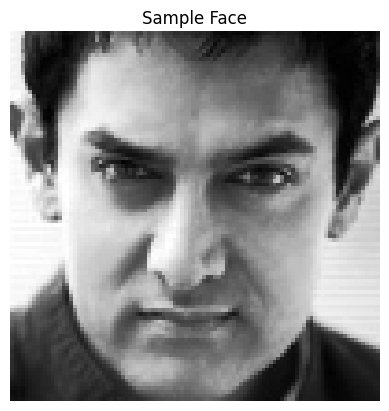

In [7]:
# Display Sample Face

sample_image = X[0].reshape(100,100)

plt.imshow(sample_image, cmap='gray')

plt.title("Sample Face")

plt.axis('off')

plt.show()

In [8]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (270, 10000)
Testing Shape: (180, 10000)


In [9]:
# Mean Face

mean_face = np.mean(X_train, axis=0)

print("Mean Face Shape:", mean_face.shape)

Mean Face Shape: (10000,)


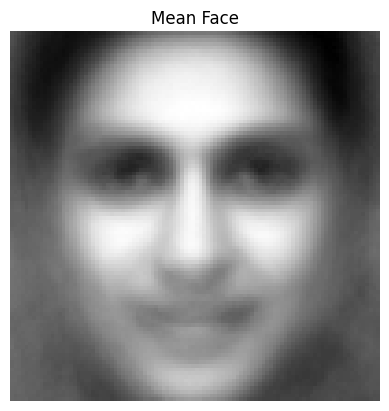

In [10]:
# Display Mean Face

mean_face_image = mean_face.reshape(100,100)

plt.imshow(mean_face_image, cmap='gray')

plt.title("Mean Face")

plt.axis('off')

plt.show()

In [11]:
# Mean Centering

X_train_centered = X_train - mean_face

X_test_centered = X_test - mean_face

In [12]:
# Apply PCA

k = 150

pca = PCA(n_components=k)

X_train_pca = pca.fit_transform(X_train_centered)

X_test_pca = pca.transform(X_test_centered)

print("PCA Train Shape:", X_train_pca.shape)

print("PCA Test Shape:", X_test_pca.shape)

PCA Train Shape: (270, 150)
PCA Test Shape: (180, 150)


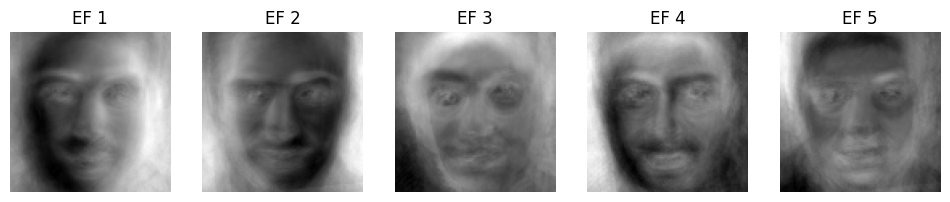

In [13]:
# Display Eigenfaces

eigenfaces = pca.components_

plt.figure(figsize=(12,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(eigenfaces[i].reshape(100,100), cmap='gray')

    plt.title(f"EF {i+1}")

    plt.axis('off')

plt.show()

In [14]:
# Train SVM Model

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True
)

svm_model.fit(X_train_pca, y_train)

print("SVM Training Completed")

SVM Training Completed


In [15]:
# Predict Test Data

y_pred = svm_model.predict(X_test_pca)

In [16]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 69.44444444444444


In [17]:
# Show Predictions

for i in range(10):

    print("Actual Person:", label_map[y_test[i]])

    print("Predicted Person:", label_map[y_pred[i]])

    print()

Actual Person: Disha
Predicted Person: Alia

Actual Person: Amitabh
Predicted Person: Amitabh

Actual Person: Alia
Predicted Person: Disha

Actual Person: Ileana
Predicted Person: Ileana

Actual Person: Disha
Predicted Person: Deepika

Actual Person: Disha
Predicted Person: Disha

Actual Person: Ajay
Predicted Person: Aamir

Actual Person: Akshay
Predicted Person: Akshay

Actual Person: Deepika
Predicted Person: Deepika

Actual Person: Deepika
Predicted Person: Akshay



In [18]:
# Accuracy vs k Graph

k_values = [10,20,30,40,50,75,100,125,150]

accuracies = []

In [19]:
# Compare Different k Values

for k in k_values:

    pca = PCA(n_components=k)

    X_train_pca = pca.fit_transform(X_train_centered)

    X_test_pca = pca.transform(X_test_centered)

    svm_model = SVC(
        kernel='rbf',
        C=10,
        gamma='scale',
        probability=True
    )

    svm_model.fit(X_train_pca, y_train)

    y_pred = svm_model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc * 100)

    print("k =", k, "Accuracy =", acc * 100)

k = 10 Accuracy = 55.55555555555556
k = 20 Accuracy = 63.888888888888886
k = 30 Accuracy = 62.22222222222222
k = 40 Accuracy = 65.55555555555556
k = 50 Accuracy = 65.55555555555556
k = 75 Accuracy = 67.22222222222223
k = 100 Accuracy = 68.88888888888889
k = 125 Accuracy = 69.44444444444444
k = 150 Accuracy = 68.33333333333333


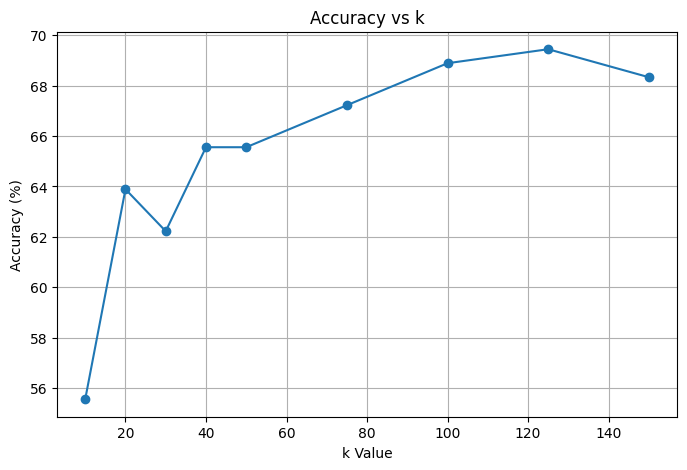

In [20]:
# Plot Accuracy vs k

plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("k Value")

plt.ylabel("Accuracy (%)")

plt.title("Accuracy vs k")

plt.grid(True)

plt.show()

In [21]:
# Imposter Detection

probabilities = svm_model.predict_proba(
    X_test_pca[0].reshape(1,-1)
)

confidence = np.max(probabilities)

print("Confidence:", confidence)

if confidence < 0.6:

    print("Unknown Person")

else:

    predicted_class = np.argmax(probabilities)

    print("Recognized:", label_map[predicted_class])

Confidence: 0.4713244105090145
Unknown Person


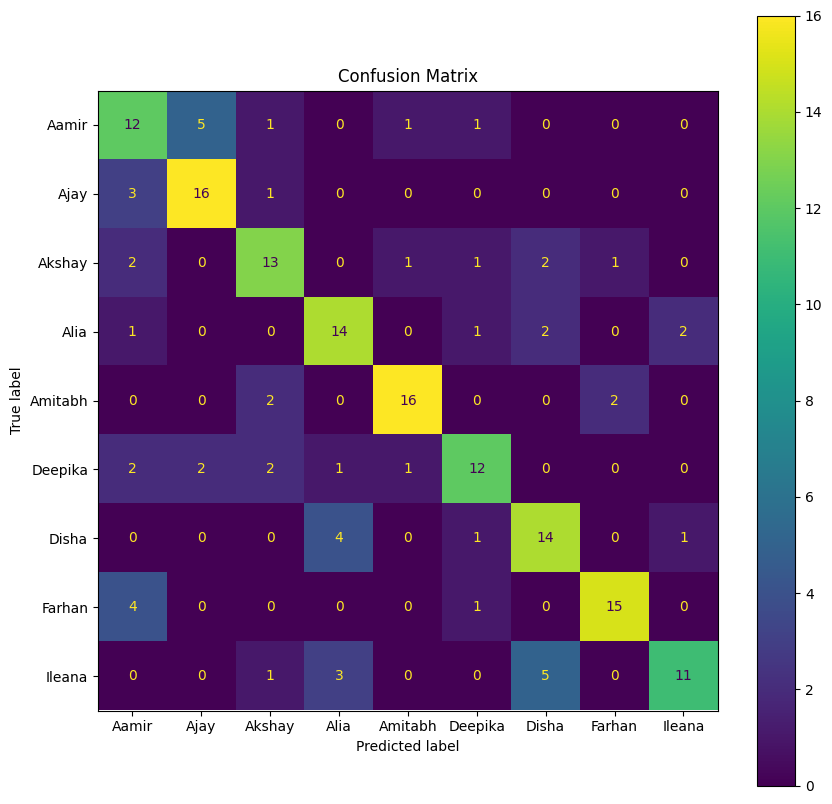

In [22]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_map.values()
)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(ax=ax)

plt.title("Confusion Matrix")

plt.show()

In [23]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=label_map.values()
))

              precision    recall  f1-score   support

       Aamir       0.50      0.60      0.55        20
        Ajay       0.70      0.80      0.74        20
      Akshay       0.65      0.65      0.65        20
        Alia       0.64      0.70      0.67        20
     Amitabh       0.84      0.80      0.82        20
     Deepika       0.71      0.60      0.65        20
       Disha       0.61      0.70      0.65        20
      Farhan       0.83      0.75      0.79        20
      Ileana       0.79      0.55      0.65        20

    accuracy                           0.68       180
   macro avg       0.70      0.68      0.68       180
weighted avg       0.70      0.68      0.68       180

